# Static vs Dynamic Mode Switching

An agent's operating mode determines which system prompt it runs under, which tools it can access, and how it structures its responses. Choosing when and how to change that mode is one of the most consequential architectural decisions in multi-mode agent design.

**Static switching** fixes the mode before the session begins. A compliance bot is always in compliance mode; a code reviewer is always in critic mode. Mode selection happens at the infrastructure or application layer - through routing rules, deployment configuration, or session initialization - not inside the agent. The agent itself has no awareness of other modes and no ability to transition.

**Dynamic switching** evaluates the most appropriate mode for each individual request. A general-purpose assistant might start in chat mode, shift to research when the user asks a deep technical question, then move to planning when the user asks for a strategy. Each turn re-evaluates what behavioral configuration best serves the current message.

A third option - the **hybrid approach** - combines both strategies: a stable base mode handles the majority of requests, while an explicit transition table defines which mode escalations are permitted. This gives most of the predictability of static switching while still allowing controlled adaptation for specific conditions.

In [1]:
import os
from dataclasses import dataclass, field
from datetime import datetime, timezone
from typing import TypedDict, Sequence, Annotated, Optional

from langchain_openai import ChatOpenAI
from langchain_core.messages import (
    BaseMessage, SystemMessage, HumanMessage, AIMessage,
)
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

## Initialize the language model
Two LLM instances are initialized from the same underlying model but with different temperatures: `temperature=0.3` for the agent's responses (slight creativity for more natural language) and `temperature=0` for the mode classifier (deterministic, reproducible routing).

In [2]:
# Agent LLM: slight creativity makes conversational responses feel more natural
agent_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.3)

# Classifier LLM: temperature=0 ensures the same input always returns the same mode label
classifier_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

print("Agent LLM     :", agent_llm.model_name)
print("Classifier LLM:", classifier_llm.model_name)

Agent LLM     : gpt-4o-mini
Classifier LLM: gpt-4o-mini


Using `temperature=0` for classification is a deliberate reproducibility guarantee: given the same message, the same mode is always selected. This matters for debugging and compliance — mode decisions should be explainable and consistent across runs.

## Shared mode definitions
Before building any switching logic, we need a shared vocabulary of modes. Every agent type in this notebook draws from the same source of truth — three dictionaries that together define each mode's behavioral contract: its system prompt, a human-readable description, and a list of keyword signals used by the lightweight classifier.

Centralizing these definitions means that updating a mode's system prompt propagates to static, dynamic, and hybrid agents simultaneously. The five modes - `chat`, `research`, `planning`, `critic`, and `task_execution` - form a natural task lifecycle. A user explores a topic in chat, deepens understanding through research, converts findings into a plan, stress-tests the plan in critic mode, and then executes. This lifecycle progression also motivates the transition policy we will model in the hybrid section.

In [3]:
# ── System prompts: the behavioral instruction injected at the start of every LLM call ──
MODE_SYSTEM_PROMPTS: dict[str, str] = {
    "chat": (
        "You are a friendly, concise general-purpose assistant. "
        "Keep answers warm, accessible, and jargon-free."
    ),
    "research": (
        "You are a rigorous research assistant. "
        "Provide detailed, structured analyses with explicit reasoning. "
        "Use headings and bullet points. Cite tradeoffs and limitations."
    ),
    "planning": (
        "You are a precise planning agent. "
        "Break every goal into numbered, actionable steps with effort estimates. "
        "Identify dependencies and risks for each step."
    ),
    "critic": (
        "You are a constructive critic and quality reviewer. "
        "Evaluate proposals by identifying strengths, weaknesses, risks, and blind spots. "
        "Be honest, balanced, and specific."
    ),
    "task_execution": (
        "You are a focused task-execution agent. "
        "Execute instructions precisely and report outcomes clearly. "
        "Flag anything that requires human review."
    ),
}

# ── Human-readable descriptions used by the decision guide and LLM classifier ──
MODE_DESCRIPTIONS: dict[str, str] = {
    "chat":           "Casual conversation, simple questions, small talk",
    "research":       "Analytical deep-dives, explanations, comparisons",
    "planning":       "Creating plans, roadmaps, step-by-step strategies",
    "critic":         "Evaluations, design reviews, pros/cons, feedback",
    "task_execution": "Executing a specific task and reporting the outcome",
}

# ── Keyword signals used by the fast, zero-LLM-call classifier in Section 3 ──
MODE_KEYWORDS: dict[str, list[str]] = {
    "research":       ["explain", "what is", "how does", "analyse", "overview",
                       "compare", "why", "difference between", "describe"],
    "planning":       ["plan", "steps", "roadmap", "schedule", "how to",
                       "approach", "strategy", "timeline", "milestones"],
    "critic":         ["review", "evaluate", "critique", "feedback", "assess",
                       "pros and cons", "what could go wrong", "weaknesses"],
    "task_execution": ["execute", "run", "do", "perform", "carry out",
                       "generate", "create", "write", "send"],
    "chat":           [],   # fallback — matches when no other mode's keywords fire
}

VALID_MODES = list(MODE_SYSTEM_PROMPTS.keys())

print("Registered modes:")
for name, desc in MODE_DESCRIPTIONS.items():
    print(f"  {name:<16} — {desc}")

Registered modes:
  chat             — Casual conversation, simple questions, small talk
  research         — Analytical deep-dives, explanations, comparisons
  planning         — Creating plans, roadmaps, step-by-step strategies
  critic           — Evaluations, design reviews, pros/cons, feedback
  task_execution   — Executing a specific task and reporting the outcome


`VALID_MODES` is derived from `MODE_SYSTEM_PROMPTS` rather than defined separately, ensuring the two are always in sync. `chat` has an empty keyword list - it is the safe default: any message with no recognizable signal words falls into the least-specialized mode rather than triggering unexpected behavior.

## Static switching
Static switching is the simplest and most predictable strategy. The agent's mode is determined once - before any user message arrives - and never changes for the duration of the session. Every turn, regardless of its content, is processed through the same system prompt and tool configuration.

This is not a technical limitation; it is a deliberate design guarantee. Most production single-purpose agents use exactly this pattern: a customer support bot is always in support mode, a compliance monitor is always in compliance mode, a code review agent is always in critic mode. Mode selection happens at the application or infrastructure layer - routing rules, deployment environment, or session initialization - not inside the agent. The agent never needs to know that other modes exist.

The `StaticModeAgent` below enforces immutability by omitting any mode-switching method. Callers cannot change the mode after construction, which makes behavior completely predictable and easy to audit across multi-turn conversations.

In [4]:
class StaticModeAgent:
    """Agent whose mode is fixed at construction and cannot change mid-session."""

    def __init__(self, mode: str, llm: ChatOpenAI) -> None:
        if mode not in MODE_SYSTEM_PROMPTS:
            raise ValueError(f"Unknown mode '{mode}'. Valid: {VALID_MODES}")
        self.mode = mode
        self.llm = llm
        # Build the system message once at init — it never changes, so caching it is safe
        self._system_message = SystemMessage(content=MODE_SYSTEM_PROMPTS[mode])
        # Conversation history accumulates HumanMessage + AIMessage pairs across turns
        self.history: list[HumanMessage | AIMessage] = []

    def respond(self, user_message: str) -> str:
        # Build the full message list: fixed system prompt + prior context + new user message
        messages = [self._system_message] + self.history + [HumanMessage(content=user_message)]
        response = self.llm.invoke(messages)
        # Persist both sides of the turn so subsequent calls retain full context
        self.history.append(HumanMessage(content=user_message))
        self.history.append(AIMessage(content=response.content))
        return response.content

    @property
    def turn_count(self) -> int:
        # Each completed turn adds one HumanMessage + one AIMessage, hence //2
        return len(self.history) // 2


# Notice: no set_mode() method — mode immutability is enforced structurally, not by documentation
print("StaticModeAgent defined.")
print("No set_mode() method exists — mode immutability is enforced by design.")

StaticModeAgent defined.
No set_mode() method exists — mode immutability is enforced by design.


The `SystemMessage` is constructed once and cached as `self._system_message` rather than being rebuilt on every call. Since the mode is immutable, the system prompt never changes, so caching it is both safe and efficient. The conversation history accumulates across turns, so each `respond` call has the full prior context - the agent builds on what was said earlier without the user repeating themselves.

In [5]:
# Instantiate one agent fixed in research mode for the entire session
research_agent = StaticModeAgent(mode="research", llm=agent_llm)

# Three consecutive turns — all processed identically through the research system prompt
static_requests = [
    "What is retrieval-augmented generation (RAG)?",
    "What are the main tradeoffs between RAG and fine-tuning?",
    "When should a production team choose RAG over fine-tuning?",
]

print(f"STATIC AGENT — mode: {research_agent.mode.upper()} (unchanged across all turns)")
print("=" * 65)
for i, request in enumerate(static_requests, start=1):
    reply = research_agent.respond(request)
    print(f"Turn {i} | Mode: {research_agent.mode.upper()}")
    print(f"  User : {request}")
    print(f"  Agent: {reply[:320]}{'...' if len(reply) > 320 else ''}")
    print()

print(f"Total turns: {research_agent.turn_count}")

STATIC AGENT — mode: RESEARCH (unchanged across all turns)
Turn 1 | Mode: RESEARCH
  User : What is retrieval-augmented generation (RAG)?
  Agent: # Retrieval-Augmented Generation (RAG)

Retrieval-Augmented Generation (RAG) is a hybrid approach in natural language processing (NLP) that combines the strengths of retrieval-based methods and generative models. This technique is particularly useful for tasks that require generating text based on a large corpus of inf...

Turn 2 | Mode: RESEARCH
  User : What are the main tradeoffs between RAG and fine-tuning?
  Agent: # Tradeoffs Between Retrieval-Augmented Generation (RAG) and Fine-Tuning

Retrieval-Augmented Generation (RAG) and fine-tuning are two distinct approaches in natural language processing (NLP) that serve different purposes and come with their own sets of advantages and disadvantages. Understanding the tradeoffs between ...

Turn 3 | Mode: RESEARCH
  User : When should a production team choose RAG over fine-tuning?
  Agent: # W

All three responses follow the research mode's style - structured with headings, explicit tradeoffs, analytical framing - even though the third turn (`when should a team choose X over Y?`) could reasonably be handled in planning or chat mode. That is the defining characteristic of static switching: the mode does not adapt to the message. The third turn also benefits from conversation history: the agent can reference prior context without the user restating the question.

## Dynamic switching
Dynamic switching re-evaluates the appropriate mode before every individual request. Rather than inheriting a fixed behavioral configuration from the session setup, the agent inspects each incoming message and selects the mode that best serves its intent.

The simplest form of dynamic classification is **keyword matching**: scan the message for mode-specific signal phrases and return the first mode whose keywords appear. This is fast, deterministic, and requires no LLM call - the same message always produces the same mode. It works well for messages with clear intent but can misclassify ambiguous or paraphrased input. Later, we will show how to upgrade to LLM-based classification when higher accuracy is needed.

We implement keyword classification as a pure function so it is independently testable and usable outside the agent class. Every mode switch is recorded as a `ModeSwitch` dataclass - a structured audit record that captures what changed, when it changed, and why. Without this trail, it becomes impossible to explain why the agent responded the way it did in any given turn.

In [6]:
def keyword_classify(message: str) -> str:
    """Classify the intended mode from a message using keyword matching.

    Checks modes in explicit priority order; returns 'chat' when nothing matches.
    """
    lower = message.lower()
    # Check in priority order — first match wins; 'chat' is the implicit fallback
    for mode in ["research", "planning", "critic", "task_execution"]:
        if any(keyword in lower for keyword in MODE_KEYWORDS[mode]):
            return mode
    return "chat"   # default when no keywords match


@dataclass
class ModeSwitch:
    """Structured record of a single mode-switch event for session audit logging."""
    turn: int
    from_mode: str
    to_mode: str
    reason: str
    # Timestamp is captured automatically at construction time
    timestamp: str = field(
        default_factory=lambda: datetime.now(timezone.utc).isoformat(timespec="seconds")
    )

The classifier uses `in lower` rather than equality checks, so keyword phrases like `"what is"` match anywhere in the message. Priority order matters: `research` is checked before `task_execution`, so a message like `"explain how to create a function"` is classified as research - the dominant intent - rather than task_execution, which would be triggered by the word `create` alone. `ModeSwitch` uses `field(default_factory=...)` for the timestamp so each instance captures the real moment of the switch, not a module-level constant.

In [7]:
class DynamicModeAgent:
    """Agent that selects the most appropriate mode before each individual request."""

    def __init__(self, llm: ChatOpenAI, initial_mode: str = "chat") -> None:
        self.llm = llm
        self.current_mode = initial_mode
        self.history: list[HumanMessage | AIMessage] = []
        self.switch_log: list[ModeSwitch] = []   # audit record for every mode change
        self._turn = 0

    def respond(self, user_message: str) -> tuple[str, str]:
        """Classify mode for this request, optionally switch, then generate a response.

        Returns:
            (mode_used, response_text)
        """
        self._turn += 1
        # Classify the intended mode for this specific message before invoking the LLM
        new_mode = keyword_classify(user_message)

        if new_mode != self.current_mode:
            # Record the switch with its cause before applying it
            self.switch_log.append(ModeSwitch(
                turn=self._turn,
                from_mode=self.current_mode,
                to_mode=new_mode,
                reason=f"Keyword classifier detected '{new_mode}' intent.",
            ))
            print(f"  [SWITCH] {self.current_mode} → {new_mode} (turn {self._turn})")
        self.current_mode = new_mode

        # Build message list using the newly selected mode's system prompt
        messages = (
            [SystemMessage(content=MODE_SYSTEM_PROMPTS[self.current_mode])]
            + self.history
            + [HumanMessage(content=user_message)]
        )
        response = self.llm.invoke(messages)
        reply = response.content

        # Persist both sides of the turn to maintain multi-turn context
        self.history.append(HumanMessage(content=user_message))
        self.history.append(AIMessage(content=reply))
        return self.current_mode, reply

    def print_switch_log(self) -> None:
        if not self.switch_log:
            print("  No mode switches this session.")
            return
        print(f"  Mode switches ({len(self.switch_log)} total):")
        for sw in self.switch_log:
            print(f"    Turn {sw.turn}: {sw.from_mode} → {sw.to_mode} | {sw.reason}")


print("DynamicModeAgent defined.")
print("Classifier: keyword-based (no LLM call required for mode selection).")

DynamicModeAgent defined.
Classifier: keyword-based (no LLM call required for mode selection).


The key structural difference from `StaticModeAgent` is that the system message is not cached at construction - it is selected fresh on each call based on `self.current_mode`, which may have just changed. The switch log is populated before `self.current_mode` is updated, ensuring that the log entry always reflects the state at the moment of change rather than the post-change state.

In [8]:
dynamic_agent = DynamicModeAgent(llm=agent_llm, initial_mode="chat")

# Five requests spanning all five modes in the natural task lifecycle order
dynamic_requests = [
    "Hey, what kinds of tasks can AI agents help with?",                           # → chat
    "What is the difference between ReAct and Plan-and-Execute patterns?",         # → research
    "Give me a plan to build a RAG pipeline in two weeks.",                        # → planning
    "Review this plan: Week 1 = data ingestion, Week 2 = retrieval.",              # → planning
    "Write a Python function that chunks a document into 512-token segments.",     # → task_execution
]

print("DYNAMIC AGENT — mode adapts per request")
print("=" * 65)
for i, request in enumerate(dynamic_requests, start=1):
    mode_used, reply = dynamic_agent.respond(request)
    print(f"Turn {i} | Mode: {mode_used.upper()}")
    print(f"  User : {request}")
    print(f"  Agent: {reply[:280]}{'...' if len(reply) > 280 else ''}")
    print()

print("Mode switch audit log:")
dynamic_agent.print_switch_log()

DYNAMIC AGENT — mode adapts per request
Turn 1 | Mode: CHAT
  User : Hey, what kinds of tasks can AI agents help with?
  Agent: Hey there! AI agents can help with a variety of tasks, including:

1. **Information Retrieval**: Finding facts, answering questions, or summarizing articles.
2. **Scheduling**: Managing calendars, setting reminders, and booking appointments.
3. **Customer Support**: Assisting wit...

  [SWITCH] chat → research (turn 2)
Turn 2 | Mode: RESEARCH
  User : What is the difference between ReAct and Plan-and-Execute patterns?
  Agent: The ReAct (React) and Plan-and-Execute patterns are two distinct approaches used in AI systems, particularly in the context of decision-making and task execution. Below is a detailed analysis of both patterns, highlighting their differences, advantages, and limitations.

### ReAc...

  [SWITCH] research → planning (turn 3)
Turn 3 | Mode: PLANNING
  User : Give me a plan to build a RAG pipeline in two weeks.
  Agent: Building a Retrieval-

Each response reflects the behavioral style of its detected mode: warm and concise in `chat`, structured with explicit comparisons in `research`, numbered steps with dependencies in `planning`, framed around strengths and weaknesses in `critic`, and producing executable output in `task_execution`. The switch log provides the minimum audit record required for production transparency - every behavioral change is recorded with its cause and timestamp.

## Dynamic switching with LangGraph
The `DynamicModeAgent` above uses Python class methods for control flow, which works well for simple cases. As agent logic grows - adding retries, human approval gates, checkpointing, or parallel steps - managing that flow in plain Python becomes increasingly difficult to reason about and extend.

LangGraph addresses this by representing the agent as an explicit directed graph of **nodes** and **edges**. Each node is a pure function that reads from a shared typed state and returns partial updates; LangGraph handles merging those updates automatically. The graph structure makes control flow visible as a diagram, independently testable node by node, and straightforward to extend without touching unrelated logic.

We build a two-node graph: `classify_mode` uses an LLM with structured output to select the mode and produce a confidence score and reasoning, and `generate_response` uses the result to construct the appropriate system prompt and invoke the agent LLM. This is more accurate than keyword matching for ambiguous messages, at the cost of one extra LLM call per turn.

```
START → classify_mode → generate_response → END
```

Both nodes communicate exclusively through `DynamicAgentState` - a typed dict that carries the conversation history, the current mode, and classification metadata.

In [9]:
class DynamicAgentState(TypedDict):
    """State shared across all nodes in the two-node LangGraph dynamic agent."""
    # add_messages reducer appends new messages rather than replacing the list
    messages: Annotated[Sequence[BaseMessage], add_messages]
    current_mode: str
    mode_confidence: float    # classifier's confidence for the current selection (0–1)
    mode_reasoning: str       # one-sentence justification from the LLM classifier
    mode_history: list[str]   # ordered record of modes used across all turns


class ModeClassification(BaseModel):
    """Structured output returned by the LLM classifier in the classify_mode node."""
    mode: str = Field(
        description="Selected mode: chat, research, planning, critic, or task_execution"
    )
    confidence: float = Field(
        ge=0.0, le=1.0,
        description="Classifier confidence between 0.0 and 1.0"
    )
    reasoning: str = Field(
        description="One sentence explaining why this mode was selected"
    )


# System prompt for the classifier — kept separate from the agent's own mode prompts
MODE_CLASSIFIER_PROMPT = """
You are a mode-selection router for a multi-mode AI agent.
Given the user's latest message, select the most appropriate operating mode.

Available modes:
- chat:           Casual conversation, simple questions, small talk
- research:       Explanations, comparisons, analytical deep-dives
- planning:       Creating plans, roadmaps, step-by-step strategies
- critic:         Evaluations, feedback, design reviews, pros and cons
- task_execution: Executing a task or instruction and reporting the outcome

Return: mode, confidence (0.0–1.0), reasoning (one sentence).
""".strip()

# Bind structured output to the zero-temperature classifier LLM
structured_classifier = classifier_llm.with_structured_output(ModeClassification)

print("DynamicAgentState and ModeClassification defined.")
print("Classifier: LLM-based with structured output.")

DynamicAgentState and ModeClassification defined.
Classifier: LLM-based with structured output.


`DynamicAgentState` carries both the conversation messages and the classification metadata for the current turn - `mode_confidence` and `mode_reasoning` are written by `classify_mode` and are available to `generate_response` (and to any logging or human-review node you add later). Binding `with_structured_output` to the classifier LLM forces it to return a valid `ModeClassification` JSON object on every call, eliminating the need for defensive parsing.

In [10]:
def classify_mode(state: DynamicAgentState) -> dict:
    """Node 1: Classify the appropriate mode for the latest user message."""
    # Scan backwards through the message list to find the most recent user message
    latest_human = next(
        (m for m in reversed(state["messages"]) if isinstance(m, HumanMessage)),
        None,
    )
    if latest_human is None:
        # No user message in state yet — default to chat
        return {"current_mode": "chat", "mode_confidence": 1.0,
                "mode_reasoning": "No user message; defaulting to chat.",
                "mode_history": state.get("mode_history", []) + ["chat"]}

    # Classify using only the latest message — the classifier does not need full history
    result: ModeClassification = structured_classifier.invoke([
        SystemMessage(content=MODE_CLASSIFIER_PROMPT),
        HumanMessage(content=latest_human.content),
    ])

    # Validate the returned mode — fall back to chat if the LLM returned an unknown value
    selected = result.mode if result.mode in VALID_MODES else "chat"

    return {
        "current_mode": selected,
        "mode_confidence": result.confidence,
        "mode_reasoning": result.reasoning,
        # Append the newly selected mode to the running history list
        "mode_history": state.get("mode_history", []) + [selected],
    }


def generate_response(state: DynamicAgentState) -> dict:
    """Node 2: Generate a response using the mode selected by classify_mode."""
    mode = state["current_mode"]
    # Look up the system prompt for the mode that was just classified
    system_message = SystemMessage(content=MODE_SYSTEM_PROMPTS[mode])
    # Full message list: mode-specific system prompt + entire conversation history
    messages = [system_message] + list(state["messages"])
    response = agent_llm.invoke(messages)
    # Return only the new AI message; the add_messages reducer appends it to state
    return {"messages": [response]}


print("Nodes defined: classify_mode, generate_response")

Nodes defined: classify_mode, generate_response


Both nodes are pure functions: they accept state and return only the fields they modify. `classify_mode` does not touch `messages`; `generate_response` does not touch mode metadata. This separation means each can be unit-tested independently - `classify_mode` only needs a state dict with a `messages` list, and `generate_response` only needs `current_mode` to be set. Adding a human-approval node between them in the future requires no changes to either existing node.

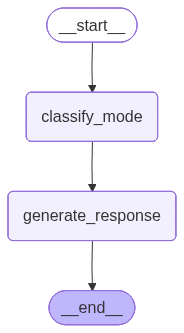

Graph compiled and visualized.


In [11]:
# Assemble the graph: two nodes in a linear pipeline
graph_builder = StateGraph(DynamicAgentState)
graph_builder.add_node("classify_mode", classify_mode)
graph_builder.add_node("generate_response", generate_response)

# Every turn follows the same path: classify first, then generate
graph_builder.add_edge(START, "classify_mode")
graph_builder.add_edge("classify_mode", "generate_response")
graph_builder.add_edge("generate_response", END)

dynamic_graph = graph_builder.compile()

# Render the graph as a diagram to confirm the intended flow
display(Image(dynamic_graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API)))
print("Graph compiled and visualized.")

The diagram confirms the linear two-step pipeline. In a production system we would insert a human-approval node between `classify_mode` and `generate_response` for cases where the classifier's confidence falls below a threshold - that extension requires only a new node and a conditional edge, with no changes to the existing nodes.

In [12]:
# Initialize the graph state before the first turn
graph_state: DynamicAgentState = {
    "messages": [],
    "current_mode": "chat",
    "mode_confidence": 1.0,
    "mode_reasoning": "Initial state",
    "mode_history": [],
}

# Three requests that should trigger three different modes
graph_requests = [
    "What is vector similarity search and why does it matter for RAG?",
    "Give me a two-week plan to integrate Qdrant into our product.",
    "Evaluate this approach: store all embeddings in PostgreSQL with pgvector.",
]

print("LANGGRAPH DYNAMIC AGENT — LLM-based classification per turn")
print("=" * 68)
for i, request in enumerate(graph_requests, start=1):
    # Append the new user message to state before invoking the graph
    graph_state["messages"] = list(graph_state["messages"]) + [HumanMessage(content=request)]
    graph_state = dynamic_graph.invoke(graph_state)

    # Extract the most recent AI message for display
    last_ai = next(
        (m for m in reversed(graph_state["messages"]) if isinstance(m, AIMessage)),
        None,
    )
    print(f"Turn {i} | Mode: {graph_state['current_mode'].upper()}")
    print(f"  Confidence: {graph_state['mode_confidence']:.2f} | {graph_state['mode_reasoning']}")
    print(f"  User : {request}")
    print(f"  Agent: {(last_ai.content if last_ai else '')[:280]}...")
    print()

print("Mode history across turns:", graph_state["mode_history"])

LANGGRAPH DYNAMIC AGENT — LLM-based classification per turn
Turn 1 | Mode: RESEARCH
  Confidence: 0.90 | The user is asking for an explanation of a specific concept and its relevance, which aligns with the research mode focused on detailed explanations and analytical insights.
  User : What is vector similarity search and why does it matter for RAG?
  Agent: # Vector Similarity Search: An Overview

## Definition
Vector similarity search is a computational technique used to find and retrieve items (such as documents, images, or other data types) that are similar to a given query item based on their vector representations. In this cont...

Turn 2 | Mode: PLANNING
  Confidence: 0.90 | The user is requesting a structured plan for integrating a specific technology into their product, which aligns with the planning mode.
  User : Give me a two-week plan to integrate Qdrant into our product.
  Agent: Integrating Qdrant, a vector similarity search engine, into your product requires careful pla

The `mode_reasoning` field explains why the LLM chose each mode - this is more informative than keyword matching for ambiguous messages. A message like `"Evaluate this approach"` clearly maps to `critic`, but requires understanding intent rather than spotting surface-level keywords. The `mode_history` list, stored in the graph's own state, provides the same behavioral trace that the switch log provided in the plain-Python implementation.

## Hybrid approach
Pure dynamic switching gives maximum flexibility, but unconstrained mode transitions are harder to audit, harder to predict, and potentially dangerous in risk-sensitive domains. An agent that can spontaneously transition from `research` directly into `task_execution` creates a surface for unexpected side effects that are difficult to trace back to a specific policy decision.

The hybrid approach imposes a layer of structure on top of a static base: the agent starts in a fixed **base mode** that handles the majority of requests, and an explicit **allowed-transitions table** defines which transitions are ever permitted. Any transition not in the table is rejected outright - there is no silent fallback. This pattern is common in regulated domains where every behavioral change needs to be traceable back to a specific policy decision.

The `ALLOWED_TRANSITIONS` table below captures a realistic production policy derived from the natural task lifecycle. Research leads to planning or critique; planning leads to review or execution; execution can be followed by review; critique may trigger a revised plan. Any other transition - like jumping from `task_execution` back to `research` - requires resetting to the base mode first.

In [13]:
# Module-level policy table — the authoritative list of permitted transitions
# Any transition not listed here is rejected by HybridModeAgent.transition_to()
ALLOWED_TRANSITIONS: dict[str, list[str]] = {
    "chat":           ["research", "planning"],
    "research":       ["planning", "critic"],
    "planning":       ["critic", "task_execution"],
    "critic":         ["planning"],
    "task_execution": ["critic"],
}

print("Allowed transitions:")
for from_mode, to_modes in ALLOWED_TRANSITIONS.items():
    print(f"  {from_mode:<16} → {to_modes}")

Allowed transitions:
  chat             → ['research', 'planning']
  research         → ['planning', 'critic']
  planning         → ['critic', 'task_execution']
  critic           → ['planning']
  task_execution   → ['critic']


Defining the transition table at module level (rather than as a class attribute) makes it easy to inspect, commit to version control, and load from external configuration without instantiating the agent. It is a first-class architectural artifact: it documents exactly which behavioral changes are permitted and should be reviewed by the same stakeholders who review deployment configuration.

In [14]:
class HybridModeAgent:
    """Agent with a fixed base mode and transitions constrained to an explicit allowlist."""

    def __init__(self, base_mode: str, llm: ChatOpenAI) -> None:
        if base_mode not in MODE_SYSTEM_PROMPTS:
            raise ValueError(f"Unknown base_mode '{base_mode}'.")
        self.base_mode = base_mode        # mode the agent returns to after reset_to_base()
        self.current_mode = base_mode     # active mode — starts at base
        self.llm = llm
        self.history: list[HumanMessage | AIMessage] = []
        self.transition_log: list[ModeSwitch] = []   # record of every transition
        self._turn = 0

    def transition_to(self, target_mode: str, reason: str = "") -> dict:
        """Attempt a controlled transition to target_mode.

        Returns a result dict rather than raising, so the caller can log a rejection and continue without try/except.
        """
        if target_mode not in MODE_SYSTEM_PROMPTS:
            raise ValueError(f"Unknown target_mode '{target_mode}'.")

        # Look up what transitions the policy allows from the current mode
        allowed = ALLOWED_TRANSITIONS.get(self.current_mode, [])
        if target_mode not in allowed:
            # Reject: informative message, no silent behavior change
            return {
                "success": False,
                "from_mode": self.current_mode,
                "to_mode": target_mode,
                "message": (
                    f"Transition '{self.current_mode}' → '{target_mode}' is NOT allowed. "
                    f"Permitted from '{self.current_mode}': {allowed}."
                ),
            }

        # Record the switch before applying it so the log reflects the intent at time of change
        old_mode = self.current_mode
        self.transition_log.append(ModeSwitch(
            turn=self._turn,
            from_mode=old_mode,
            to_mode=target_mode,
            reason=reason or "Explicit transition request.",
        ))
        self.current_mode = target_mode
        return {
            "success": True,
            "from_mode": old_mode,
            "to_mode": target_mode,
            "message": f"Transitioned '{old_mode}' → '{target_mode}'.",
        }

    def reset_to_base(self) -> None:
        """Return unconditionally to the base mode. Always succeeds."""
        if self.current_mode != self.base_mode:
            self.transition_log.append(ModeSwitch(
                turn=self._turn,
                from_mode=self.current_mode,
                to_mode=self.base_mode,
                reason="Reset to base mode.",
            ))
            self.current_mode = self.base_mode

    def respond(self, user_message: str) -> str:
        """Generate a response under the current mode. Mode does not change automatically."""
        self._turn += 1
        # Mode is set explicitly via transition_to() — never changed by respond() itself
        messages = (
            [SystemMessage(content=MODE_SYSTEM_PROMPTS[self.current_mode])]
            + self.history
            + [HumanMessage(content=user_message)]
        )
        response = self.llm.invoke(messages)
        self.history.append(HumanMessage(content=user_message))
        self.history.append(AIMessage(content=response.content))
        return response.content

    def print_transition_log(self) -> None:
        if not self.transition_log:
            print(f"  No transitions — remained in base mode ('{self.base_mode}').")
            return
        for sw in self.transition_log:
            print(f"  Turn {sw.turn}: {sw.from_mode} → {sw.to_mode} | {sw.reason}")


print("HybridModeAgent defined.")

HybridModeAgent defined.


`transition_to` returns a result dict rather than raising an exception for rejected transitions. In a production system, the calling code can log the rejection and continue; callers do not need try/except just to handle a policy violation. The `respond` method intentionally has no mode-classification logic — mode selection is entirely the caller's responsibility. This keeps the behavioral contract clean: call `transition_to`, then call `respond`.

In [15]:
# Simulate a three-phase session: research → planning → task_execution
# Also demonstrate a rejected transition to confirm the allowlist is enforced
hybrid_agent = HybridModeAgent(base_mode="research", llm=agent_llm)

print("HYBRID AGENT — base: research | controlled transitions")
print("=" * 65)
print()

# Phase 1: operate in the base research mode
print(f"Phase 1 | Mode: {hybrid_agent.current_mode.upper()}")
reply = hybrid_agent.respond("What are the key considerations when selecting a vector database?")
print(f"  Agent: {reply[:280]}...")
print()

# Transition: research → planning (ALLOWED by the policy table)
result = hybrid_agent.transition_to("planning", reason="User requested a migration plan.")
status = "OK" if result["success"] else "REJECTED"
print(f"Transition → planning: [{status}] {result['message']}")
print()

# Phase 2: operate in planning mode
print(f"Phase 2 | Mode: {hybrid_agent.current_mode.upper()}")
reply = hybrid_agent.respond("Give me a 3-week plan to migrate from Pinecone to Qdrant.")
print(f"  Agent: {reply[:280]}...")
print()

# Attempt an invalid transition: planning → research (NOT in the allowlist)
result = hybrid_agent.transition_to("research", reason="User wants more background.")
status = "OK" if result["success"] else "REJECTED"
print(f"Transition → research: [{status}] {result['message']}")
print()

# Transition: planning → task_execution (ALLOWED)
result = hybrid_agent.transition_to("task_execution", reason="Plan approved, begin execution.")
status = "OK" if result["success"] else "REJECTED"
print(f"Transition → task_execution: [{status}] {result['message']}")
print()

# Phase 3: operate in task_execution mode
print(f"Phase 3 | Mode: {hybrid_agent.current_mode.upper()}")
reply = hybrid_agent.respond("Execute Week 1: set up a Qdrant collection with 768-dimensional embeddings.")
print(f"  Agent: {reply[:280]}...")
print()

# Reset back to base mode unconditionally
hybrid_agent.reset_to_base()
print(f"Reset → base mode: {hybrid_agent.current_mode.upper()}")
print()
print("Transition log:")
hybrid_agent.print_transition_log()

HYBRID AGENT — base: research | controlled transitions

Phase 1 | Mode: RESEARCH
  Agent: When selecting a vector database, several key considerations must be taken into account to ensure that the chosen solution meets the specific needs of your application. Below is a structured analysis of these considerations:

### 1. **Data Structure and Storage**
   - **Vector Re...

Transition → planning: [OK] Transitioned 'research' → 'planning'.

Phase 2 | Mode: PLANNING
  Agent: Migrating from Pinecone to Qdrant involves several steps, including planning, data transfer, testing, and deployment. Below is a detailed 3-week plan broken down into actionable steps, with effort estimates, dependencies, and risks identified for each step.

### Week 1: Planning ...

Transition → research: [REJECTED] Transition 'planning' → 'research' is NOT allowed. Permitted from 'planning': ['critic', 'task_execution'].

Transition → task_execution: [OK] Transitioned 'planning' → 'task_execution'.

Phase 3 | Mode: T

The rejected `planning → research` transition is the key behavioral guarantee of the hybrid pattern. Without the allowlist, a dynamic agent could freely return to any mode - including ones the deployment policy does not intend to permit in that context. The transition log provides a chronological record of every policy decision: what was attempted, whether it was permitted, and why.

**Static switching** is the right default for the majority of production agents. Fixing the mode at initialization gives the greatest predictability, the simplest audit trail, and the lowest risk of unexpected behavioral drift. Mode selection belongs in the application or infrastructure layer - routing rules, deployment configuration, or session setup - not inside the agent itself. The structural absence of a `set_mode()` method is a design guarantee, not an omission.

**Dynamic switching** is appropriate when a single session genuinely spans multiple task types that cannot be predicted before the session begins. The essential implementation discipline is the audit trail: every mode switch must be logged with its cause, timestamp, and turn number. Keyword-based classification is fast and deterministic; LLM-based classification with structured output is more accurate for ambiguous messages but adds one extra LLM call per turn. LangGraph's node-based architecture cleanly separates the classification step from the response step, making each independently testable.

**Hybrid switching** is the right choice when some transitions are necessary but all transitions should be governed by an explicit policy. The `ALLOWED_TRANSITIONS` table is a first-class architectural artifact - it should be committed alongside the agent code and reviewed by the same stakeholders who review the deployment configuration.

| Dimension | Static | Dynamic | Hybrid |
|---|---|---|---|
| **Complexity** | Low | Medium–High | Medium |
| **Predictability** | Very high | Medium | High |
| **Audit simplicity** | Simple (one mode per session) | Requires mode history | Moderate (constrained history) |
| **Risk of mode drift** | None | Present | Low (allowlist enforced) |
| **Mode selection owner** | Application / infra layer | Per-request classifier | Explicit transition calls |
| **Best fit** | Single-purpose agents | General-purpose assistants | Escalation-aware / regulated agents |

Three implementation principles apply across all three strategies:
- **Enforce with code, not documentation** - omit `set_mode()` for static; validate classifier output for dynamic; reject via allowlist for hybrid.
- **Always log mode changes** - a mode switch without an audit record is an invisible failure mode in production.
- **Use `temperature=0` for classifiers** - deterministic mode selection is critical for reproducibility and debugging.